# Dívida pública brasileira: trajetória, juros e composição (2000–2026)

Análise das séries mensais mais longas localizadas nas fontes oficiais. Os dados do Tesouro cobrem o estoque agregado da Dívida Pública Federal (DPF) de dezembro de 2000 a agosto de 2026; o Banco Central fornece a Dívida Bruta do Governo Geral (DBGG) como percentual do PIB de dezembro de 2006 a agosto de 2026. O último mês depende da publicação mais recente disponível na data da coleta (6 de outubro de 2026).

**Fontes:** [Tesouro — estoque da DPF](https://www.tesourotransparente.gov.br/ckan/dataset/0998f610-bc25-4ce3-b32c-a873447500c2), [fatores de variação](https://www.tesourotransparente.gov.br/ckan/dataset/fatores-de-variacao-da-divida-publica-federal), [emissões e resgates](https://www.tesourotransparente.gov.br/ckan/dataset/emissoes-e-resgates-divida-publica-federal), [BCB — DBGG/PIB, SGS 13762](https://dadosabertos.bcb.gov.br/dataset/13762-divida-bruta-do-governo-geral--pib---metodologia-utilizada-a-partir-de-2008), [BCB — DLGG/PIB, SGS 4536](https://dadosabertos.bcb.gov.br/dataset/4536-divida-liquida-do-governo-geral--pib), [BCB — IPCA, SGS 433](https://dadosabertos.bcb.gov.br/dataset/433-indice-nacional-de-precos-ao-consumidor-amplo-ipca). As fontes e os arquivos baixados estão descritos em [data/README.md](../data/README.md).

> **Escopos diferentes:** DPF é a dívida sob responsabilidade do Tesouro Nacional. DBGG inclui os governos federal, estaduais e municipais. A DBGG/PIB aparece como contexto macroeconômico; não é a DPF dividida pelo PIB. Os valores nominais da DPF são os publicados pelo Tesouro. A série real é uma transformação nossa, deflacionada pelo IPCA para reais de agosto de 2026.

## 1. Preparação e cobertura

Os arquivos brutos são preservados em `data/raw/`; as tabelas tratadas estão em `data/processed/`. Se o diretório atual não for a raiz do projeto, o código localiza a raiz pelos arquivos do projeto.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Permite executar o notebook a partir da raiz ou da pasta notebooks/.
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed"

estoque_long = pd.read_csv(DATA / "dpf_estoque_mensal.csv", parse_dates=["data"])
fatores = pd.read_csv(DATA / "dpf_fatores_mensais.csv", parse_dates=["data"])
fluxos = pd.read_csv(DATA / "dpf_emissoes_resgates_mensal.csv", parse_dates=["data"])
detalhe = pd.read_csv(DATA / "dpf_estoque_detalhado.csv", parse_dates=["data"])
posicoes = pd.read_csv(DATA / "dpf_posicoes_por_titulo.csv.gz", parse_dates=["data", "vencimento"])
bcb = pd.read_csv(DATA / "bcb_divida_ipca_mensal.csv", parse_dates=["data"])

# Indicadores principais divulgados no quadro-resumo do Tesouro.
estoque = (
    estoque_long[estoque_long["indicador"].isin(["DPF EM PODER DO PÚBLICO", "DPMFi", "DPFe ¹"])]
    .pivot(index="data", columns="indicador", values="valor_r_bilhoes")
    .rename(columns={"DPF EM PODER DO PÚBLICO": "dpf_bilhoes", "DPMFi": "dpmfi_bilhoes", "DPFe ¹": "dpfe_bilhoes"})
    .sort_index()
)

print(f"DPF: {estoque.index.min():%m/%Y} a {estoque.index.max():%m/%Y} | {len(estoque)} meses")
print(f"Fatores: {fatores.data.min():%m/%Y} a {fatores.data.max():%m/%Y}")
print(f"Emissões/resgates: {fluxos.data.min():%m/%Y} a {fluxos.data.max():%m/%Y}")
print(f"Detalhe por título: {detalhe.data.min():%m/%Y} a {detalhe.data.max():%m/%Y}")
print(f"DBGG/PIB: {bcb.loc[bcb.dbgg_percentual_pib.notna(), 'data'].min():%m/%Y} a {bcb.loc[bcb.dbgg_percentual_pib.notna(), 'data'].max():%m/%Y}")

DPF: 12/2000 a 08/2026 | 309 meses
Fatores: 01/2007 a 08/2026
Emissões/resgates: 11/2006 a 08/2026
Detalhe por título: 09/2017 a 07/2026
DBGG/PIB: 12/2006 a 08/2026


## 2. Quanto a DPF cresceu?

O valor nominal aumenta com inflação e com o tamanho da economia. Por isso, mostramos também uma série deflacionada pelo IPCA, em reais de agosto de 2026. O IPCA é encadeado a partir da variação mensal oficial. Essa transformação compara poder de compra ao longo do tempo; ela não substitui uma medida de sustentabilidade fiscal.

,DPF nominal (R$ bi),DPF em R$ de ago/2026 (R$ bi),Variação nominal em 12 meses (%)
data,,,
12/2015,2793.0,4744.9,21.7
12/2016,3112.9,4975.5,11.5
12/2017,3559.3,5526.0,14.3
12/2018,3877.1,5802.1,8.9
12/2019,4248.9,6096.1,9.6
12/2020,5009.6,6876.9,17.9
12/2021,5613.7,7001.6,12.1
12/2022,5951.4,7017.0,6.0
12/2023,6520.3,7348.2,9.6


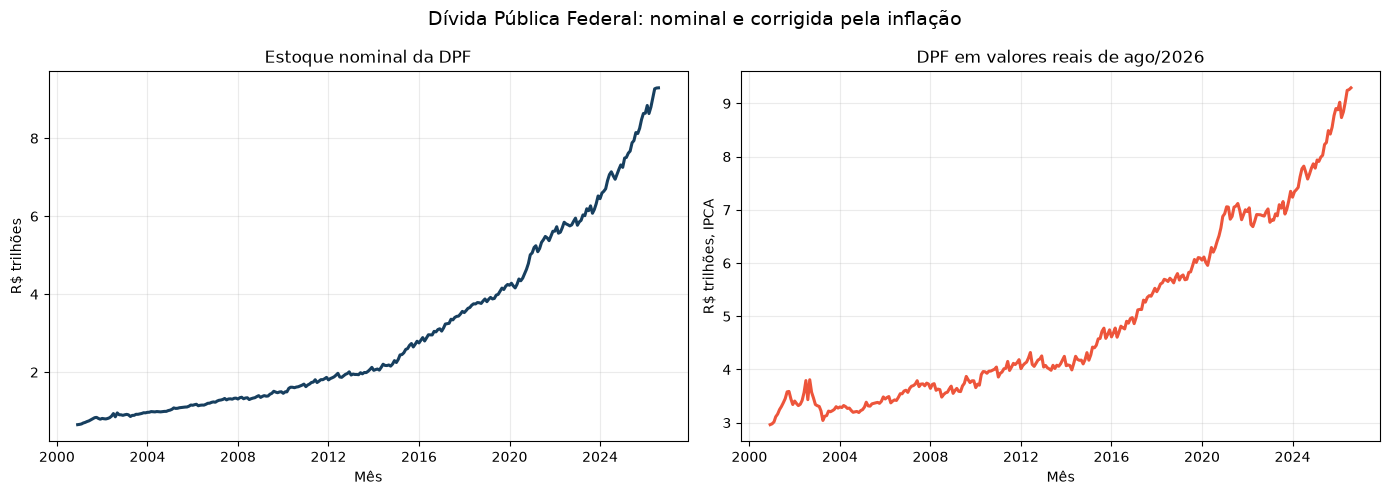

In [2]:
# Série de preços encadeada; normalizada para 1 no último mês disponível.
precos = bcb[["data", "ipca_variacao_mensal_percentual"]].dropna().sort_values("data").copy()
precos["indice_ipca"] = (1 + precos["ipca_variacao_mensal_percentual"] / 100).cumprod()
precos["deflator_agosto_2026"] = precos["indice_ipca"].iloc[-1] / precos["indice_ipca"]
serie = estoque.reset_index().merge(precos[["data", "deflator_agosto_2026"]], on="data", how="left")
serie["dpf_reais_agosto_2026_bilhoes"] = serie["dpf_bilhoes"] * serie["deflator_agosto_2026"]
serie["variacao_12m_percentual"] = serie["dpf_bilhoes"].pct_change(12) * 100

marcos = serie.set_index("data")[ ["dpf_bilhoes", "dpf_reais_agosto_2026_bilhoes", "variacao_12m_percentual"] ]
marcos = marcos.loc[[d for d in marcos.index if d.month == 12] + [marcos.index.max()]].sort_index()
marcos = marcos[~marcos.index.duplicated(keep="last")].copy()
marcos.index = marcos.index.strftime("%m/%Y")
marcos.columns = ["DPF nominal (R$ bi)", "DPF em R$ de ago/2026 (R$ bi)", "Variação nominal em 12 meses (%)"]
display(marcos.tail(12).round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(serie.data, serie.dpf_bilhoes / 1000, color="#173f5f", linewidth=2.2)
ax[0].set_title("Estoque nominal da DPF")
ax[0].set_ylabel("R$ trilhões")
ax[0].grid(alpha=.25)
ax[1].plot(serie.data, serie.dpf_reais_agosto_2026_bilhoes / 1000, color="#ed553b", linewidth=2.2)
ax[1].set_title("DPF em valores reais de ago/2026")
ax[1].set_ylabel("R$ trilhões, IPCA")
ax[1].grid(alpha=.25)
for a in ax: a.set_xlabel("Mês")
fig.suptitle("Dívida Pública Federal: nominal e corrigida pela inflação", fontsize=14)
fig.tight_layout()
plt.show()

## 3. Composição: dívida interna e externa

A DPMFi (dívida pública mobiliária federal interna) e a DPFe (externa) somam o estoque da DPF em poder do público no quadro do Tesouro. A participação externa é sensível à conversão cambial e à metodologia de avaliação da dívida externa, descrita nos metadados da fonte.

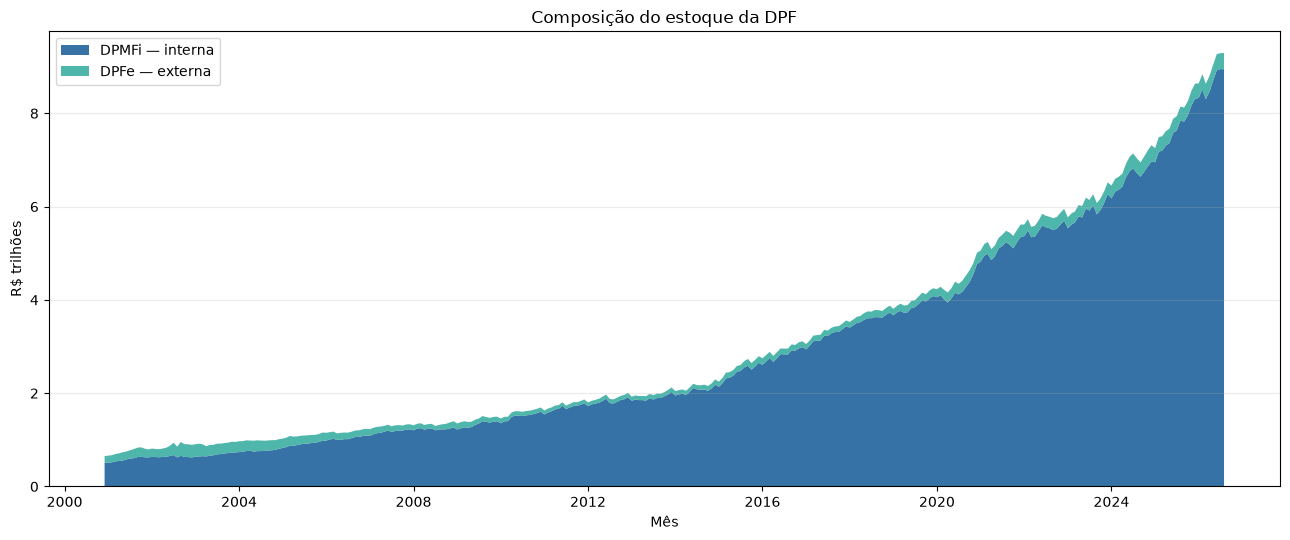

Participação da DPFe no último mês: 3.75%
Checagem DPMFi + DPFe versus total: diferença no último mês = 0.000 R$ bi


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.stackplot(estoque.index, estoque.dpmfi_bilhoes / 1000, estoque.dpfe_bilhoes / 1000,
             labels=["DPMFi — interna", "DPFe — externa"], colors=["#20639b", "#3caea3"], alpha=.9)
ax.set_title("Composição do estoque da DPF")
ax.set_ylabel("R$ trilhões")
ax.set_xlabel("Mês")
ax.grid(axis="y", alpha=.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

participacao = (estoque[["dpmfi_bilhoes", "dpfe_bilhoes"]].div(estoque.dpf_bilhoes, axis=0) * 100)
print(f"Participação da DPFe no último mês: {participacao.dpfe_bilhoes.iloc[-1]:.2f}%")
print(f"Checagem DPMFi + DPFe versus total: diferença no último mês = "
      f"{(estoque.dpmfi_bilhoes.iloc[-1] + estoque.dpfe_bilhoes.iloc[-1] - estoque.dpf_bilhoes.iloc[-1]):.3f} R$ bi")

## 4. Dívida bruta e líquida do governo geral em relação ao PIB

As séries do BCB são comparáveis ao longo do tempo dentro de cada conceito e usam percentuais do PIB. A DBGG inclui débitos dos governos federal, estaduais e municipais; a DLGG é líquida de créditos. São medidas distintas da DPF e úteis para contextualizar a dívida no tamanho da economia.

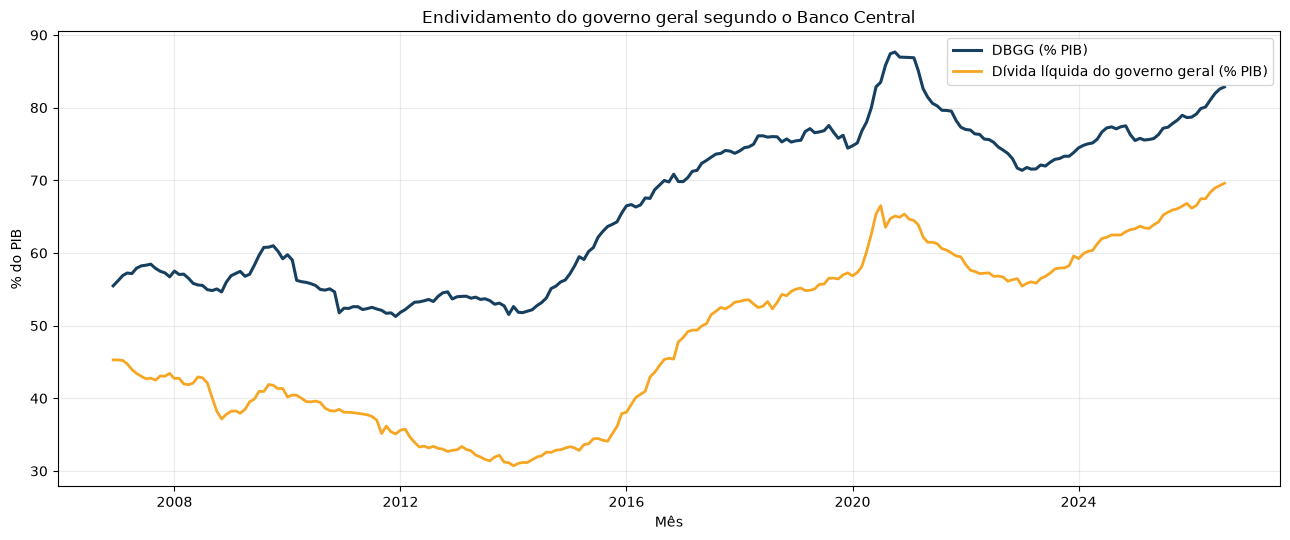

Última DBGG/PIB: 82.86% em 08/2026


In [4]:
macro = bcb.dropna(subset=["dbgg_percentual_pib"]).copy()
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(macro.data, macro.dbgg_percentual_pib, label="DBGG (% PIB)", color="#173f5f", linewidth=2.2)
ax.plot(macro.data, macro.dlgg_percentual_pib, label="Dívida líquida do governo geral (% PIB)", color="#f6a623", linewidth=2)
ax.set_title("Endividamento do governo geral segundo o Banco Central")
ax.set_ylabel("% do PIB")
ax.set_xlabel("Mês")
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

ultimos_macro = macro.dropna(subset=["dbgg_percentual_pib"]).iloc[-1]
print(f"Última DBGG/PIB: {ultimos_macro.dbgg_percentual_pib:.2f}% em {ultimos_macro.data:%m/%Y}")

## 5. Juros apropriados e emissão líquida

Os fatores do Tesouro ajudam a decompor a variação nominal da DPF. A apropriação de juros é um fator de competência e não equivale a pagamento em caixa no mesmo mês. A emissão líquida é emissão menos resgate; ela pode diferir da variação do estoque por juros, câmbio, transferências de carteira e outros fatores.

A série de juros apropriados começa em janeiro de 2007. A seção seguinte resume o fluxo anual e calcula uma taxa implícita aproximada para os anos completos, usando o estoque médio mensal da DPF.

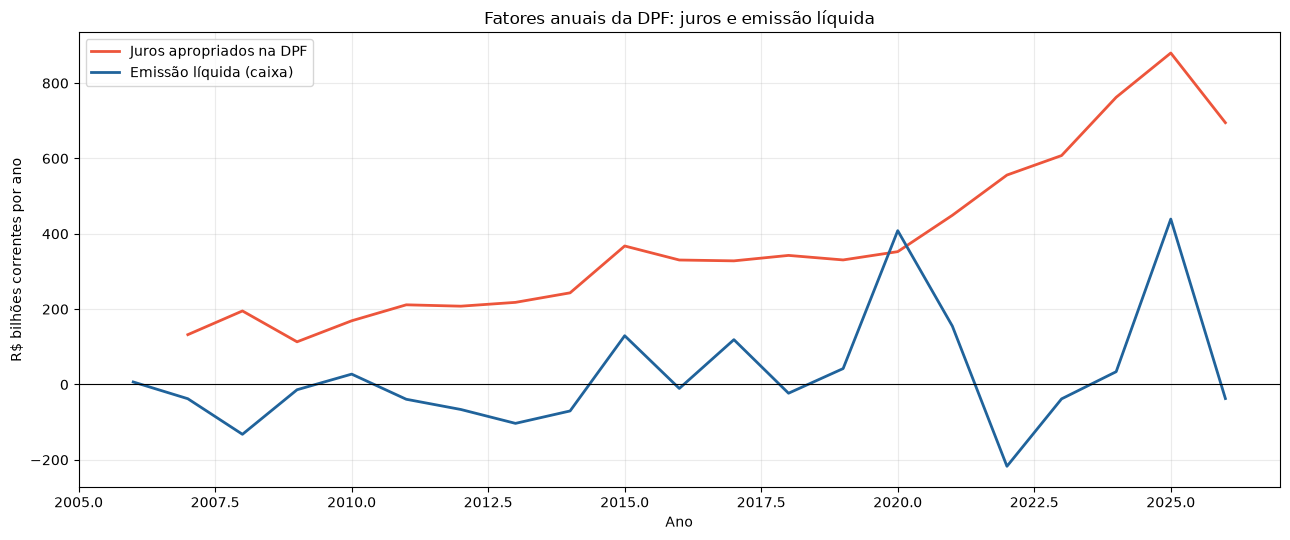

,Juros apropriados total,Emissão líquida
ano,,
2018,342.7,-23.1
2019,330.6,42.3
2020,352.6,408.3
2021,449.1,155.0
2022,556.0,-217.1
2023,607.7,-38.2
2024,762.4,34.0
2025,880.0,439.1
2026,694.9,-37.3


In [5]:
juros = fatores[fatores.indicador.isin(["- Juros Apropriados da DPMFi 9", "- Juros Apropriados da DPFe 10"])].copy()
juros["ano"] = juros.data.dt.year
juros_anual = juros.pivot_table(index="ano", columns="indicador", values="valor_r_bilhoes", aggfunc="sum").fillna(0)
juros_anual["Juros apropriados total"] = juros_anual.sum(axis=1)

liquida = fluxos[fluxos.indicador.isin(["DPMFi    (I - III)", "DPFe    (II - IV)"])].copy()
liquida["ano"] = liquida.data.dt.year
liquida_anual = liquida.groupby("ano").valor_r_bilhoes.sum().rename("Emissão líquida")

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(juros_anual.index, juros_anual["Juros apropriados total"], label="Juros apropriados na DPF", color="#ed553b", linewidth=2)
ax.plot(liquida_anual.index, liquida_anual, label="Emissão líquida (caixa)", color="#20639b", linewidth=2)
ax.axhline(0, color="black", linewidth=.8)
ax.set_title("Fatores anuais da DPF: juros e emissão líquida")
ax.set_ylabel("R$ bilhões correntes por ano")
ax.set_xlabel("Ano")
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

resumo_fatores = pd.concat([juros_anual["Juros apropriados total"], liquida_anual], axis=1).tail(10)
display(resumo_fatores.round(1))

## 5.1 Quanto representam os juros apropriados?

O valor anual soma os juros e encargos apropriados por competência, em R$ correntes. A taxa implícita é calculada como juros anuais divididos pelo estoque médio mensal da DPF no ano. Ela serve como indicador analítico agregado e **não é o custo médio oficial** divulgado pelo Tesouro, nem representa desembolso de caixa. O ano mais recente ainda incompleto aparece no fluxo, mas fica fora da taxa.

**Referências metodológicas:** [Fatores de Variação da DPF — metadados do Tesouro](https://www.tesourotransparente.gov.br/ckan/dataset/fatores-de-variacao-da-divida-publica-federal) · [Metodologia oficial dos indicadores da DPF](https://www.tesourotransparente.gov.br/publicacoes/metodologia-de-calculo-dos-indicadores-da-divida-publica/2021/30).

Juros apropriados acumulados de 2007 a 2025: R$ 6,798.2 bilhões
2025: R$ 880.0 bilhões; variação anual: 15.4%
08/2026: juros apropriados no mês de R$ 88.4 bilhões


,Juros apropriados (R$ bi),Estoque médio (R$ bi),Taxa implícita aproximada (%)
data,,,
2015,367.67,2560.95,14.36
2016,330.44,2940.87,11.24
2017,328.20,3328.72,9.86
2018,342.67,3721.41,9.21
2019,330.65,4012.13,8.24
2020,352.64,4437.26,7.95
2021,449.14,5324.73,8.44
2022,555.96,5748.96,9.67
2023,607.73,6104.72,9.96


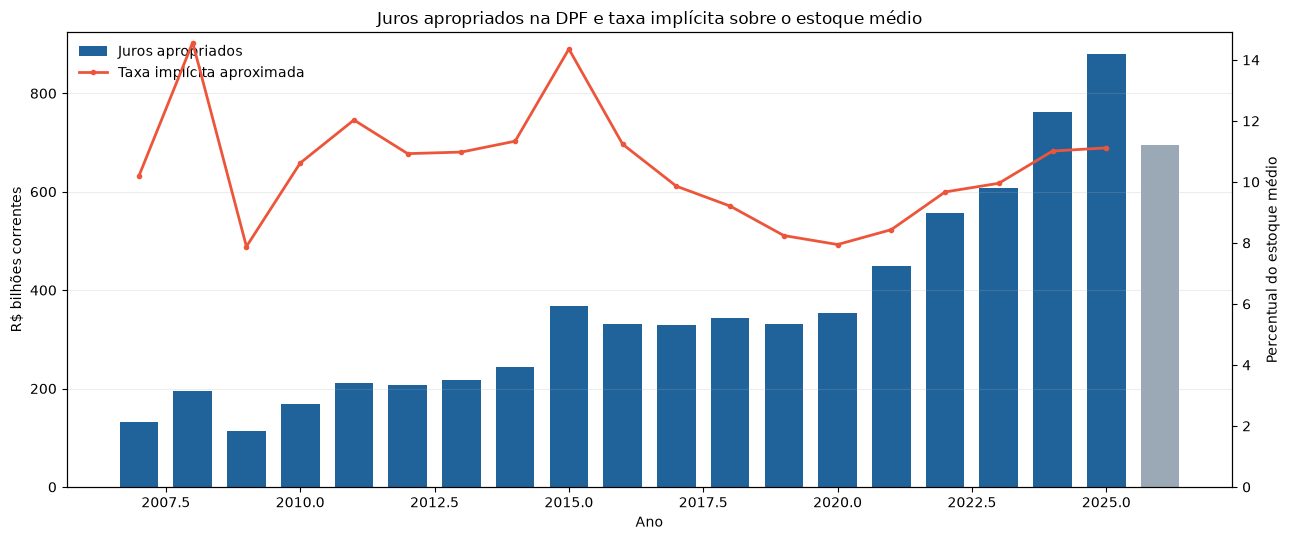

In [6]:
juros_total = (
    fatores[fatores.indicador.eq("I.2 - Juros  Apropriados")]
    .set_index("data")["valor_r_bilhoes"]
    .sort_index()
)
juros_anual_total = juros_total.groupby(juros_total.index.year).sum().rename("Juros apropriados (R$ bi)")
estoque_medio_anual = estoque["dpf_bilhoes"].groupby(estoque.index.year).mean().rename("Estoque médio (R$ bi)")
estat_juros = pd.concat([juros_anual_total, estoque_medio_anual], axis=1).dropna()
estat_juros["Taxa implícita aproximada (%)"] = 100 * estat_juros["Juros apropriados (R$ bi)"] / estat_juros["Estoque médio (R$ bi)"]

ultimo_mes_juros = juros_total.index.max()
if ultimo_mes_juros.month < 12:
    estat_juros.loc[ultimo_mes_juros.year, "Taxa implícita aproximada (%)"] = np.nan
anos_completos = estat_juros[estat_juros["Taxa implícita aproximada (%)"].notna()]
ultimo_ano_completo = int(anos_completos.index.max())

print(f"Juros apropriados acumulados de 2007 a {ultimo_ano_completo}: R$ {anos_completos['Juros apropriados (R$ bi)'].sum():,.1f} bilhões")
if ultimo_ano_completo - 1 in anos_completos.index:
    atual = anos_completos.loc[ultimo_ano_completo, "Juros apropriados (R$ bi)"]
    anterior = anos_completos.loc[ultimo_ano_completo - 1, "Juros apropriados (R$ bi)"]
    print(f"{ultimo_ano_completo}: R$ {atual:,.1f} bilhões; variação anual: {(atual / anterior - 1) * 100:.1f}%")
print(f"{ultimo_mes_juros:%m/%Y}: juros apropriados no mês de R$ {juros_total.iloc[-1]:,.1f} bilhões")
display(estat_juros.tail(12).round(2))

fig, ax = plt.subplots(figsize=(13, 5.5))
colors = ["#20639b" if year < ultimo_mes_juros.year or ultimo_mes_juros.month == 12 else "#9aa9b5" for year in estat_juros.index]
ax.bar(estat_juros.index, estat_juros["Juros apropriados (R$ bi)"], color=colors, width=.72, label="Juros apropriados")
ax.set_ylabel("R$ bilhões correntes")
ax.set_xlabel("Ano")
ax.grid(axis="y", alpha=.22)
ax2 = ax.twinx()
ax2.plot(estat_juros.index, estat_juros["Taxa implícita aproximada (%)"], color="#ed553b", marker="o", markersize=3, linewidth=2, label="Taxa implícita aproximada")
ax2.set_ylabel("Percentual do estoque médio")
ax2.set_ylim(bottom=0)
ax.set_title("Juros apropriados na DPF e taxa implícita sobre o estoque médio")
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 6. Leitura do último estoque detalhado

O CSV por título permite analisar vencimentos e carteiras, mas sua janela não é tão longa quanto a série agregada. A tabela resume a composição da última competência disponível, e o gráfico agrupa o estoque por ano de vencimento. Não extrapolamos esse detalhe para os anos anteriores.

In [7]:
ultimo_detalhe = detalhe.data.max()
perfil = detalhe[detalhe.data.eq(ultimo_detalhe)].groupby(["classe_carteira", "tipo_divida"], as_index=False).valor_r_bilhoes.sum()
perfil["valor_r_trilhoes"] = perfil.valor_r_bilhoes / 1000
print(f"Competência detalhada: {ultimo_detalhe:%m/%Y}")
display(perfil[["classe_carteira", "tipo_divida", "valor_r_trilhoes"]].round(3))

Competência detalhada: 07/2026


,classe_carteira,tipo_divida,valor_r_trilhoes
0,Banco Central,Dívida Interna,2.980
1,Mercado,Dívida Externa,0.340
2,Mercado,Dívida Interna,8.949


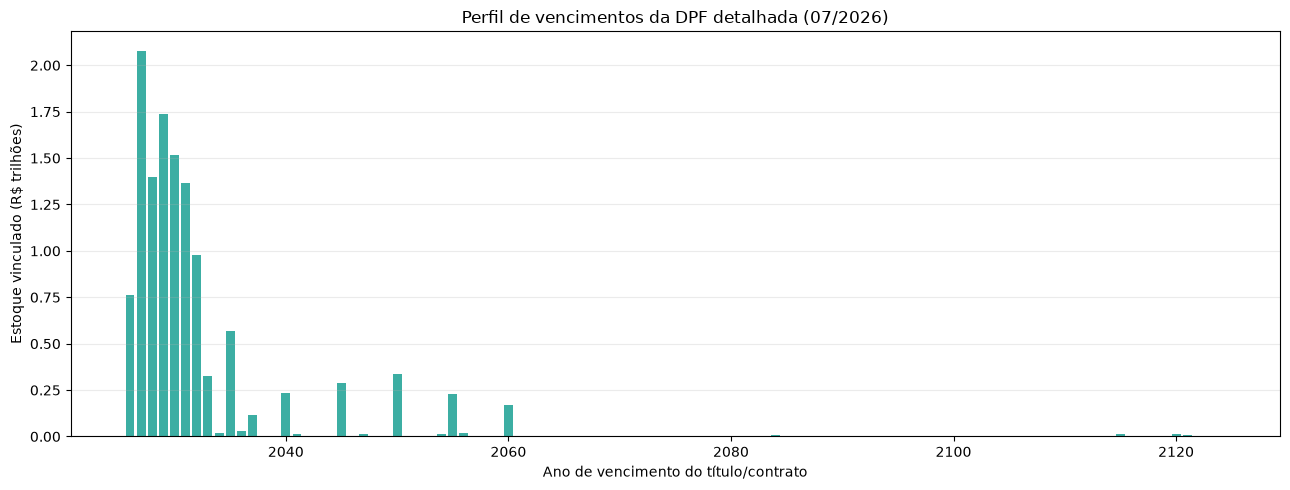

Posições detalhadas: 671; valor sem vencimento interpretável: 0.00 R$ bi


In [8]:
posicoes_ultimo_mes = posicoes[posicoes.data.eq(posicoes.data.max())].copy()
perfil_vencimentos = (
    posicoes_ultimo_mes.dropna(subset=["ano_vencimento"])
    .groupby("ano_vencimento").valor_r_bilhoes.sum().sort_index()
)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(perfil_vencimentos.index.astype(int), perfil_vencimentos.values / 1000, color="#3caea3")
ax.set_title(f"Perfil de vencimentos da DPF detalhada ({posicoes_ultimo_mes.data.max():%m/%Y})")
ax.set_xlabel("Ano de vencimento do título/contrato")
ax.set_ylabel("Estoque vinculado (R$ trilhões)")
ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()
print(f"Posições detalhadas: {len(posicoes_ultimo_mes):,}; valor sem vencimento interpretável: "
      f"{posicoes_ultimo_mes.loc[posicoes_ultimo_mes.ano_vencimento.isna(), 'valor_r_bilhoes'].sum():,.2f} R$ bi")

## 7. Síntese

- A série agregada permite acompanhar a DPF mensal por mais de 25 anos, com o último dado disponível em agosto de 2026.
- O gráfico nominal mostra a expansão em reais correntes; a série corrigida pelo IPCA reduz o efeito da inflação, mas não mede sozinha a sustentabilidade da dívida.
- A dívida interna representa a maior parcela do estoque; o detalhamento recente permite observar mercado versus carteira do Banco Central.
- A DBGG/PIB oferece um referencial macroeconômico de escopo mais amplo que a DPF. As duas medidas não devem ser somadas ou tratadas como equivalentes.
- Juros apropriados, emissão líquida e mudança do estoque são conceitos contábeis/financeiros diferentes. A decomposição do Tesouro torna visíveis esses canais e suas limitações.

### Limitações

Os órgãos podem revisar os dados e metodologias. A série de estoque longo está em R$ bilhões, enquanto as planilhas de fatores e fluxos foram convertidas de R$ milhões para R$ bilhões. O IPCA encadeado é uma transformação analítica nossa. O arquivo detalhado por título tem cobertura menor que o resumo. Os números do período corrente devem ser lidos como os últimos publicados, não como o fechamento do ano.